In [1]:
from pathlib import Path
import tempfile

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams
from spectra.normalizeddose import NormalizedDose
from spectra.spectrummodels import (
    ha_model,
    a_b_model,
    a_b_c_model,
    fit_ha_model,
    fit_a_b_model,
    fit_a_b_c_model,
)

In [2]:
monomer = ResinConstituentMonomer(data.monomers['Ideal'], 100)
absorber = ResinConstituentAbsorber(data.absorbers['ideal_uniform_absorber'], 1)
resin = Resin(monomers=monomer, absorbers=absorber)

source = data.sources['Ideal_uniform_10nm_source']
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 701))

norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=ArrayParams(0, 30, 5))

In [3]:
vars(norm_dose)

{'irradiance': <spectra.irradiance.Irradiance at 0x7fc609efb9d0>,
 'z_array_params': ArrayParams(min_value=0, max_value=30, num_pnts=5),
 'z_um': array([ 0. ,  7.5, 15. , 22.5, 30. ]),
 'source_integral': 10.133333333333326,
 'normalized_dose': array([1.        , 0.47236655, 0.22313016, 0.10539922, 0.04978707]),
 'ha_model_params': {'ha': 9.999999999935884,
  'stdev': array([3.20588896e-11])},
 'a_b_model_params': {'a': 0.9999095248013828,
  'b': 9.997707512049546,
  'stdev': array([5.22282663e-05, 1.49370145e-03])},
 'a_b_c_model_params': {'a': 0.9999214892092485,
  'b': 9.99764126693366,
  'c': 8.936863256077476e-05,
  'stdev': array([7.14662290e-05, 1.90370165e-03, 6.31842462e-05])},
 'ha_model': array([1.        , 0.47236655, 0.22313016, 0.10539922, 0.04978707]),
 'a_b_model': array([1.        , 0.47233307, 0.22312372, 0.1054258 , 0.04983881]),
 'a_b_c_model': array([1.00001086, 0.47233527, 0.22312307, 0.10542439, 0.0498373 ])}

In [4]:
np.exp(-norm_dose.z_um / 10)

array([1.        , 0.47236655, 0.22313016, 0.10539922, 0.04978707])

In [5]:
assert np.allclose(norm_dose.normalized_dose, np.exp(-norm_dose.z_um / 10))

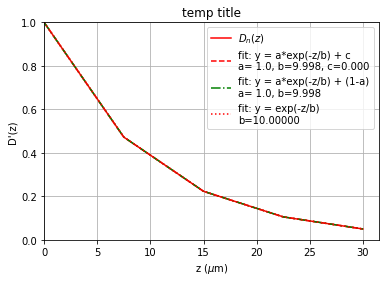

In [6]:
with tempfile.TemporaryDirectory() as d:
    temporary_file = Path(d) / 'tempfile.png'
    
    fig, ax = norm_dose.plot(title="temp title", file=temporary_file)

In [4]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bb6090>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bb6110>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bb6490>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bb6350>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bc1b50>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bb6150>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bb6050>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bd6cd0>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bd6f50>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fc6b8bd6910>,
 'sudanI_in_PEGDA_2017-04

In [2]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd89d0>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd8ed0>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd8a90>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd8f50>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6a831dd10>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd8cd0>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd86d0>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bd84d0>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fc6b8bc8250>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.S